# Minnesota Food Shelf Statistical Analysis

This notebook tests the null hypothesis:

> A county's metropolitan status has no effect on its number of food shelf locations per 10,000 residents.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
county = pd.read_pickle("data/countytable.pkl")
len(county)

87

## Mean Food Shelf Location Counts per 10k Residents

In [food_shelf_eda.ipynb](https://github.com/a-location-1/mn-food-shelf-analysis/blob/main/food_shelf_eda.ipynb), we compiled a table of the 87 Minnesota counties and classified each one according to four metropolitan classifications:
- `3`: Twin Cities core
- `2`: Seven-county metro area
- `1`: Metropolitan Statistical Area (13 MN counties)
- `0`: Non-Metro

Now we're focusing the analysis on a binary Metro (1, 2, or 3) / Non-Metro (0) split.

In [ ]:
# Adding the binary column metro:
county["metro"] = 0
county.loc[county["tcmetro"] > 0, "metro"] = 1

In [6]:
# Displaying the largest and smallest non-metro counties:
pd.concat(
    [
        county.loc[county["metro"] == 0, ["county", "population"]]
        .sort_values("population", ascending=False)
        .head(1),
        county.loc[county["metro"] == 0, ["county", "population"]]
        .sort_values("population")
        .head(1),
    ]
)

,county,population
71,St. Louis,200794
77,Traverse,3134


In [10]:
# Displaying the 13 Metro counties:
county.loc[county["metro"] == 1, ["county", "population"]].sort_values(
    "population"
).head(13)

,county,population
47,Mille Lacs,27577
39,Le Sueur,29458
29,Isanti,43687
12,Chisago,59105
69,Sherburne,103059
9,Carver,112628
85,Wright,154593
68,Scott,157206
81,Washington,283960
1,Anoka,376840


The above tables emphasize that "Non-Metro" does not mean "Rural": St. Louis, which has its county seat in Duluth, has a larger population than 8 of the 13 Metro counties. 

At the same time, the box plots below show that Non-Metro food shelf location counts are more tightly clumped than the Metro food shelf location counts are.

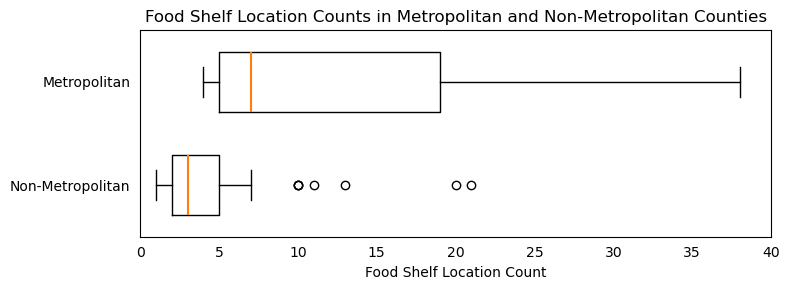

In [28]:
metro_status = [0, 1]
labels = ["Non-Metropolitan", "Metropolitan"]
plotdata = [county.loc[county["metro"] == status, "count"] for status in metro_status]

fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(
    plotdata,
    vert=False,
    patch_artist=False,
    tick_labels=labels,
    widths=0.58,
    medianprops=dict(linewidth=1.5),
)
ax.set_title("Food Shelf Location Counts in Metropolitan and Non-Metropolitan Counties")
ax.set_xlabel("Food Shelf Location Count")
ax.set_xlim(0, 40)
ax.tick_params(left=False, bottom=False)
plt.tight_layout()
plt.show()

The x-axis is restricted to 40; at 99 food shelf locations, Hennepin county is a massive outlier.

In [11]:
pd.concat(
    [
        county.groupby("metro").agg({"count": ["mean", "median"]}),
        county.groupby("metro").agg({"count_per_10k": ["mean", "median"]}),
    ], axis=1
).rename(index={0: "Non-Metro", 1: "Metro"}).round(4)

count        count_per_10k        
              mean median          mean  median
metro                                          
Non-Metro   4.1351    3.0        2.0731  1.5047
Metro      18.6923    7.0        0.8706  0.5987

Before controlling for population, Metro counties have a much higher number of average food shelf locations per county (18.69 locations versus 4.14 locations). After controlling for population, Non-Metro counties have more than double the average number of locations (2.07 count per 10k versus 0.87 count per 10k). 

Is this statistically significant?

To test this further, we'll investigate the difference between the Non-Metro mean food shelf location count per 10k minus the Metro mean food shelf location count per 10k.

In [21]:
def difference_in_means(df):
    means = df.groupby("metro")["count_per_10k"].mean()
    return np.round(means[0] - means[1],4)

In [22]:
observed_value = difference_in_means(county)
print(f"Observed value: {observed_value}")

Observed value: 1.2025


In [26]:
replicates = [observed_value]
n_sim = 20_000
sim_county = county.copy()

for _ in range(n_sim - 1):
	sim_county['metro'] = sim_county['metro'].sample(frac=1, replace=False).reset_index(drop=True)
	replicates.append(difference_in_means(sim_county))

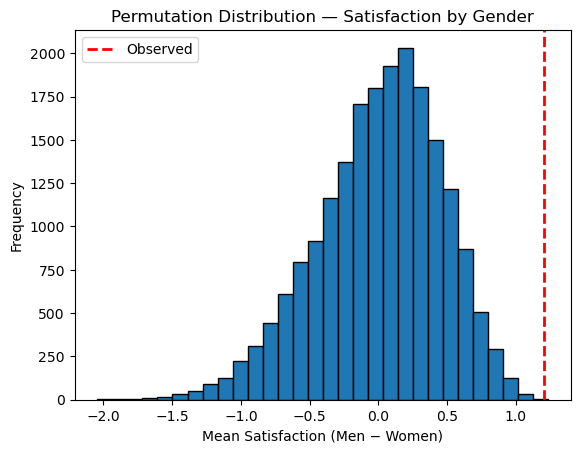

In [27]:
plt.hist(replicates, bins=30, edgecolor="black")
plt.axvline(observed_value, color="red", linestyle="--", linewidth=2, label="Observed")
plt.xlabel("Mean Satisfaction (Men − Women)")
plt.ylabel("Frequency")
plt.title("Permutation Distribution — Satisfaction by Gender")
plt.legend()
plt.show()

## Analyzing Relationship Between Metropolitanism and Food Shelf Location Counts